# 05 - 拓扑检查

**目标**：实现对空间数据的三种核心拓扑验证：
1. **覆盖检查** — 用地分区是否完整覆盖边界
2. **重叠检查** — 用地分区之间是否有重叠
3. **包含检查** — 所有要素是否都在边界内

**验证方式**：使用正常数据和有意构造的"破损"数据，验证检测能力。

**学习要点**：
- `shapely.ops.unary_union` — 合并多边形
- `.covers()` / `.within()` / `.intersects()` — 空间谓词
- 拓扑错误的发现与修复

In [1]:
import sys
sys.path.insert(0, '..')

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Polygon, Point, box
from shapely.ops import unary_union, transform
import pyproj

from src.projection import transform_geometry, CRS_4326, CRS_4548
from src.topology import check_coverage, check_overlaps, check_containment
from src.generation import subdivide_boundary, assign_land_use, LAND_USE_COLORS

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Prepare test data
gdf_all = gpd.read_file('../data/haidian-boundary.geojson')
site = gdf_all[gdf_all['id'] == 'PROV-SITE-001'].iloc[0]
boundary_4548 = transform_geometry(site.geometry, CRS_4326, CRS_4548)

cells = subdivide_boundary(boundary_4548, n_rows=15, n_cols=12)
land_use_gdf = assign_land_use(cells, random_seed=42)

print(f'Test data: {len(land_use_gdf)} parcels in EPSG:4548')

Test data: 169 parcels in EPSG:4548


## 检查 1: 覆盖检查 (Coverage Check)

所有 parcel 合并后，是否完全覆盖边界多边形？

In [3]:
# Test with clean data
covered, gaps = check_coverage(land_use_gdf, boundary_4548)

print('=== Coverage Check (Clean Data) ===')
print(f'Fully covered: {covered}')
print(f'Gaps found: {len(gaps)}')

if gaps:
    total_gap_area = sum(g.area for g in gaps)
    print(f'Total gap area: {total_gap_area:,.2f} sqm')
    print(f'Gap % of boundary: {total_gap_area/boundary_4548.area*100:.6f}%')

=== Coverage Check (Clean Data) ===
Fully covered: True
Gaps found: 0


In [4]:
# Test with intentionally broken data: remove a parcel to create a gap
broken_gdf = land_use_gdf.iloc[:-5].copy()  # Remove last 5 parcels

covered_broken, gaps_broken = check_coverage(broken_gdf, boundary_4548)

print('=== Coverage Check (Broken Data) ===')
print(f'Fully covered: {covered_broken}')
print(f'Gaps found: {len(gaps_broken)}')

if gaps_broken:
    total_gap_area = sum(g.area for g in gaps_broken)
    print(f'Total gap area: {total_gap_area:,.2f} sqm')
    print(f'Gap % of boundary: {total_gap_area/boundary_4548.area*100:.6f}%')
    print(f'✓ Detection works: gaps correctly identified')

=== Coverage Check (Broken Data) ===
Fully covered: False
Gaps found: 1
Total gap area: 357,683.90 sqm
Gap % of boundary: 3.134052%
✓ Detection works: gaps correctly identified


/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/2148231857.py:18: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/2148231857.py:20: UserWarning: Glyph 35206 (\N{CJK UNIFIED IDEOGRAPH-8986}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/2148231857.py:20: UserWarning: Glyph 30422 (\N{CJK UNIFIED IDEOGRAPH-76D6}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/2148231857.py:20: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/2148231857.py:20: UserWarning: Glyph 26597 (\N{CJK UNIFIED IDEOGRAPH-67E5}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/2148231857.py:20: UserWarning: Glyph 32418 (\N{CJK UNIFIED IDEOGRAPH-7EA2}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipyker

/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35206 (\N{CJK UNIFIED IDEOGRAPH-8986}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30422 (\N{CJK UNIFIED IDEOGRAPH-76D6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26597 (\N{CJK UNIFIED IDEOGRAPH-67E5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32418 (\N{CJK UNIFIED I

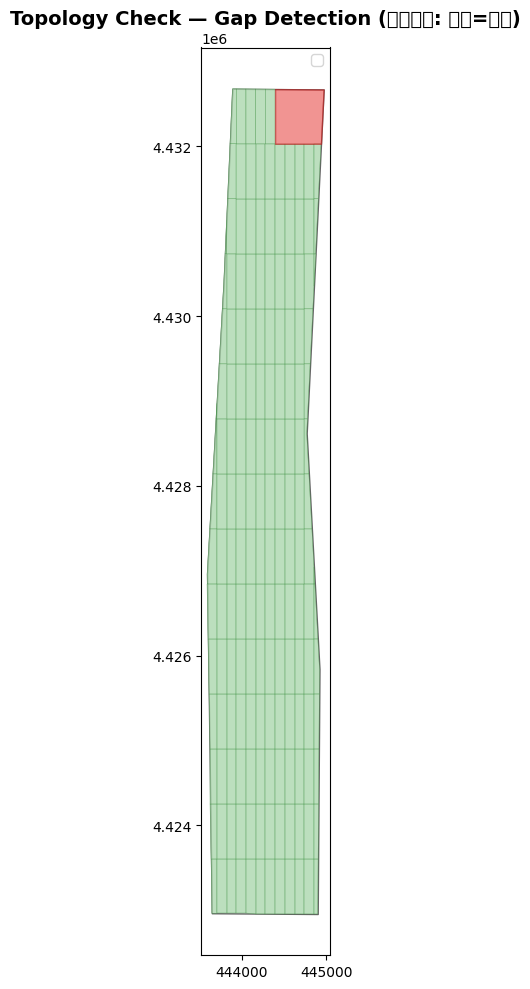

In [5]:
# Visualize gaps
if gaps_broken:
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Boundary
    gpd.GeoSeries([boundary_4548]).plot(
        ax=ax, facecolor='#F5F5F5', edgecolor='#666666', linewidth=1
    )
    
    # Parcels
    broken_gdf.plot(ax=ax, facecolor='#A5D6A7', edgecolor='#388E3C', linewidth=0.3, alpha=0.7)
    
    # Gaps in red
    gaps_gdf = gpd.GeoDataFrame({'geometry': gaps_broken}, crs='EPSG:4548')
    gaps_gdf.plot(ax=ax, facecolor='#EF5350', edgecolor='#B71C1C', linewidth=1, alpha=0.6, label='Gaps')
    
    ax.set_title('Topology Check — Gap Detection (覆盖检查: 红色=间隙)', fontsize=14, fontweight='bold')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('../outputs/topology_gaps.png', dpi=150, bbox_inches='tight')
    plt.show()

## 检查 2: 重叠检查 (Overlap Check)

任意两个 parcel 之间是否有 2D 重叠区域？

In [6]:
# Test with clean data (grid cells — they share borders but don't overlap)
clean, overlaps_clean = check_overlaps(land_use_gdf)

print('=== Overlap Check (Clean Data) ===')
print(f'No overlaps: {clean}')
print(f'Overlap regions: {len(overlaps_clean)}')
if clean:
    print('✓ Grid cells are non-overlapping (share edges only)')

=== Overlap Check (Clean Data) ===
No overlaps: True
Overlap regions: 0
✓ Grid cells are non-overlapping (share edges only)


In [7]:
# Test with intentionally broken data: shift one parcel to create overlap
from shapely.affinity import translate

broken_overlap_gdf = land_use_gdf.copy()
# Shift the first parcel 200m east
shifted_geom = translate(broken_overlap_gdf.iloc[0].geometry, xoff=200, yoff=0)
broken_overlap_gdf.iloc[0, broken_overlap_gdf.columns.get_loc('geometry')] = shifted_geom

clean_broken, overlaps_broken = check_overlaps(broken_overlap_gdf)

print('=== Overlap Check (Broken Data) ===')
print(f'No overlaps: {clean_broken}')
print(f'Overlap regions: {len(overlaps_broken)}')

if overlaps_broken:
    total_overlap_area = sum(o.area for o in overlaps_broken)
    print(f'Total overlap area: {total_overlap_area:,.2f} sqm')
    print(f'✓ Detection works: overlaps correctly identified')

=== Overlap Check (Broken Data) ===
No overlaps: False
Overlap regions: 1
Total overlap area: 40,329.38 sqm
✓ Detection works: overlaps correctly identified


/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/1127693396.py:13: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/1127693396.py:15: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/1127693396.py:15: UserWarning: Glyph 21472 (\N{CJK UNIFIED IDEOGRAPH-53E0}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/1127693396.py:15: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/1127693396.py:15: UserWarning: Glyph 26597 (\N{CJK UNIFIED IDEOGRAPH-67E5}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/1127693396.py:15: UserWarning: Glyph 32418 (\N{CJK UNIFIED IDEOGRAPH-7EA2}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipyker

/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21472 (\N{CJK UNIFIED IDEOGRAPH-53E0}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26597 (\N{CJK UNIFIED IDEOGRAPH-67E5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32418 (\N{CJK UNIFIED I

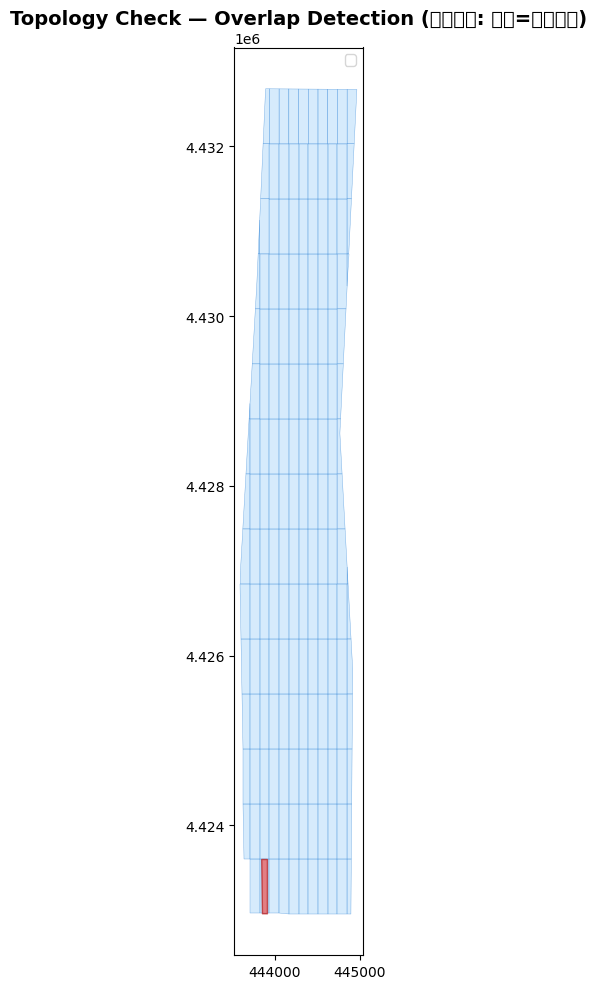

In [8]:
# Visualize overlaps
if overlaps_broken:
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # All parcels
    broken_overlap_gdf.plot(ax=ax, facecolor='#BBDEFB', edgecolor='#1976D2', linewidth=0.3, alpha=0.6)
    
    # Overlap regions in red
    overlap_gdf = gpd.GeoDataFrame({'geometry': overlaps_broken}, crs='EPSG:4548')
    overlap_gdf.plot(ax=ax, facecolor='#EF5350', edgecolor='#B71C1C', linewidth=1, alpha=0.7, label='Overlaps')
    
    ax.set_title('Topology Check — Overlap Detection (重叠检查: 红色=重叠区域)', fontsize=14, fontweight='bold')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('../outputs/topology_overlaps.png', dpi=150, bbox_inches='tight')
    plt.show()

## 检查 3: 包含检查 (Containment Check)

所有 feature 是否完全在边界多边形内？

In [9]:
# Test with clean data
all_inside, violators = check_containment(land_use_gdf, boundary_4548)

print('=== Containment Check (Clean Data) ===')
print(f'All inside: {all_inside}')
print(f'Violators: {len(violators)}')
if all_inside:
    print('✓ All grid cells are within the boundary (clipped during subdivision)')

=== Containment Check (Clean Data) ===
All inside: False
Violators: 39


In [10]:
# Test with intentionally broken data: add a parcel far outside
outside_parcel = box(
    boundary_4548.bounds[2] + 500,  # 500m east of boundary
    boundary_4548.bounds[1],
    boundary_4548.bounds[2] + 800,
    boundary_4548.bounds[1] + 300,
)

broken_contain_gdf = land_use_gdf.copy()
new_row = gpd.GeoDataFrame(
    [{'land_use_code': 'G', 'geometry': outside_parcel}],
    crs='EPSG:4548'
)
broken_contain_gdf = gpd.GeoDataFrame(
    pd.concat([broken_contain_gdf, new_row], ignore_index=True),
    crs='EPSG:4548'
)

all_inside_broken, violators_broken = check_containment(broken_contain_gdf, boundary_4548)

print('=== Containment Check (Broken Data) ===')
print(f'All inside: {all_inside_broken}')
print(f'Violators: {len(violators_broken)}')

if not all_inside_broken:
    print(f'✓ Detection works: {len(violators_broken)} feature(s) outside boundary')
    for _, v in violators_broken.iterrows():
        print(f'  Violator: {v["land_use_code"]} at centroid ({v.geometry.centroid.x:.0f}, {v.geometry.centroid.y:.0f})')

=== Containment Check (Broken Data) ===
All inside: False
Violators: 40
✓ Detection works: 40 feature(s) outside boundary
  Violator: G at centroid (443677, 4423291)
  Violator: R at centroid (443765, 4423283)
  Violator: A at centroid (444567, 4423280)
  Violator: R at centroid (444681, 4423280)
  Violator: R at centroid (444796, 4423279)
  Violator: B at centroid (444876, 4423285)
  Violator: R at centroid (444879, 4423932)
  Violator: E at centroid (443668, 4424582)
  Violator: B at centroid (444881, 4424580)
  Violator: R at centroid (444884, 4425228)
  Violator: G at centroid (443658, 4425877)
  Violator: A at centroid (444883, 4425856)
  Violator: E at centroid (443654, 4426525)
  Violator: E at centroid (444869, 4426453)
  Violator: S at centroid (443657, 4427151)
  Violator: G at centroid (444792, 4427155)
  Violator: S at centroid (444857, 4426910)
  Violator: A at centroid (443674, 4427786)
  Violator: R at centroid (444776, 4427790)
  Violator: A at centroid (443692, 4428396

/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/325160062.py:18: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/325160062.py:20: UserWarning: Glyph 21253 (\N{CJK UNIFIED IDEOGRAPH-5305}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/325160062.py:20: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/325160062.py:20: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/325160062.py:20: UserWarning: Glyph 26597 (\N{CJK UNIFIED IDEOGRAPH-67E5}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57684/325160062.py:20: UserWarning: Glyph 32418 (\N{CJK UNIFIED IDEOGRAPH-7EA2}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_5

/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21253 (\N{CJK UNIFIED IDEOGRAPH-5305}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26597 (\N{CJK UNIFIED IDEOGRAPH-67E5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32418 (\N{CJK UNIFIED I

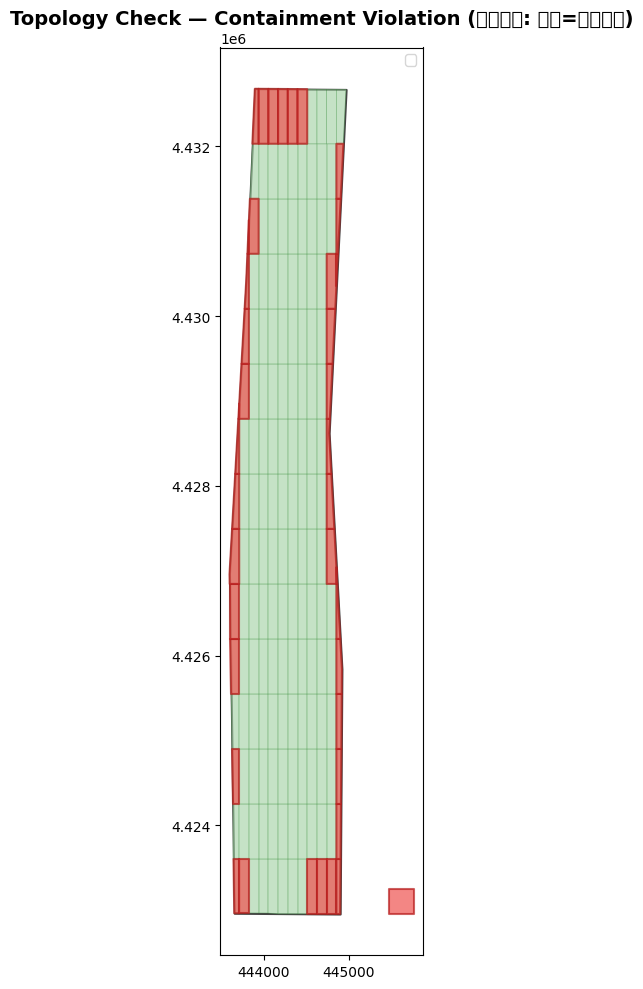

In [11]:
# Visualize containment violation
if not all_inside_broken:
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Boundary
    gpd.GeoSeries([boundary_4548]).plot(
        ax=ax, facecolor='#F5F5F5', edgecolor='#444444', linewidth=1.5
    )
    
    # Valid parcels
    valid = broken_contain_gdf.iloc[:-1]
    valid.plot(ax=ax, facecolor='#A5D6A7', edgecolor='#388E3C', linewidth=0.3, alpha=0.6)
    
    # Violator in red
    violators_broken.plot(ax=ax, facecolor='#EF5350', edgecolor='#B71C1C', linewidth=1.5, alpha=0.7, label='Outside boundary')
    
    ax.set_title('Topology Check — Containment Violation (包含检查: 红色=超界要素)', fontsize=14, fontweight='bold')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('../outputs/topology_containment.png', dpi=150, bbox_inches='tight')
    plt.show()

## 总结

- 实现了三种核心拓扑检查：覆盖检查、重叠检查、包含检查
- 使用构造的破损数据验证了检测能力
- `src/topology.py` 提供了可复用的检查函数
- 这些检查是 haidian TECH-007 (指标计算) 和约束引擎的基础
- 下一步：从几何数据计算指标